## Descripción del Proyecto

Este proyecto construye un pipeline de aprendizaje automático para predecir si un cliente recomendará un producto, utilizando texto de reseñas, variables numéricas y categóricas.

El pipeline incluye etapas de preprocesamiento de datos, entrenamiento del modelo y ajuste de hiperparámetros utilizando herramientas de scikit-learn.

# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [3]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

## Exploración de Datos

En esta sección se analizan los datos para identificar valores faltantes y entender la distribución de la variable objetivo.

Esto permite tomar decisiones informadas para la construcción del pipeline.

In [4]:
# Check missing values
print("Missing values:\n")
print(X.isnull().sum())

# Check target balance
print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Missing values:

Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

Target distribution:
Recommended IND
1    0.816235
0    0.183765
Name: proportion, dtype: float64


### Observaciones

- No se encontraron valores faltantes en el dataset, por lo que no es necesario aplicar técnicas de imputación.
- La variable objetivo está desbalanceada, con aproximadamente 81% de valores positivos (recomendado) y 19% negativos.
- Este desbalance puede afectar el rendimiento del modelo, especialmente en la clase minoritaria.

## Building Pipeline

## Construcción del Pipeline

Se construye un pipeline utilizando `ColumnTransformer` para manejar distintos tipos de datos:

- Texto: transformado mediante TF-IDF
- Variables numéricas: escaladas con StandardScaler
- Variables categóricas: codificadas con OneHotEncoder

Este enfoque permite integrar el preprocesamiento y el modelo en un solo flujo.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
text_features = ['Review Text']
numeric_features = ['Age', 'Positive Feedback Count']
categorical_features = ['Division Name', 'Department Name', 'Class Name']

In [7]:
# Preprocesamiento de texto utilizando vectorización TF-IDF (técnica de NLP)
text_transformer = TfidfVectorizer(stop_words='english')

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, 'Review Text'),
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## Training Pipeline

## Entrenamiento del Modelo

Se utiliza un modelo de regresión logística dentro de un pipeline completo.

El modelo es entrenado con los datos de entrenamiento para aprender patrones que permitan predecir si un cliente recomendará un producto.

In [9]:
from sklearn.linear_model import LogisticRegression

# Create full pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [10]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(stop_words='english'),
                                                  'Review Text'),
                                                 ('num', StandardScaler(),
                                                  ['Age',
                                                   'Positive Feedback Count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Division Name',
                                                   'Department Name',
                                                   'Class Name'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.49      0.59       327
           1       0.90      0.96      0.93      1518

    accuracy                           0.88      1845
   macro avg       0.82      0.73      0.76      1845
weighted avg       0.87      0.88      0.87      1845



### Evaluación del Modelo

El modelo presenta un buen desempeño general con una precisión cercana al 88%.

- La clase positiva (clientes que recomiendan) muestra métricas altas de precisión y recall.
- La clase negativa tiene un rendimiento menor, lo cual es esperado debido al desbalance en los datos.

En general, el modelo logra capturar correctamente los patrones principales del dataset.

## Fine-Tuning Pipeline

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

grid = GridSearchCV(model, param_grid, cv=3, n_jobs=-1)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'classifier__C': 10, 'classifier__class_weight': None}


In [14]:
# Predicciones con el mejor modelo
y_pred = grid.predict(X_test)

# Evaluación
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.60      0.65       327
           1       0.92      0.94      0.93      1518

    accuracy                           0.88      1845
   macro avg       0.81      0.77      0.79      1845
weighted avg       0.88      0.88      0.88      1845



## Ajuste de Hiperparámetros

Se realizó una búsqueda en cuadrícula (GridSearchCV) para optimizar el modelo, evaluando diferentes valores del parámetro de regularización (C) y el balanceo de clases.

El mejor conjunto de parámetros encontrado fue:

- C = 10  
- class_weight = None  

El uso de diferentes combinaciones permitió mejorar el rendimiento del modelo, especialmente en la clase minoritaria.

In [15]:
y_pred = grid.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.60      0.65       327
           1       0.92      0.94      0.93      1518

    accuracy                           0.88      1845
   macro avg       0.81      0.77      0.79      1845
weighted avg       0.88      0.88      0.88      1845



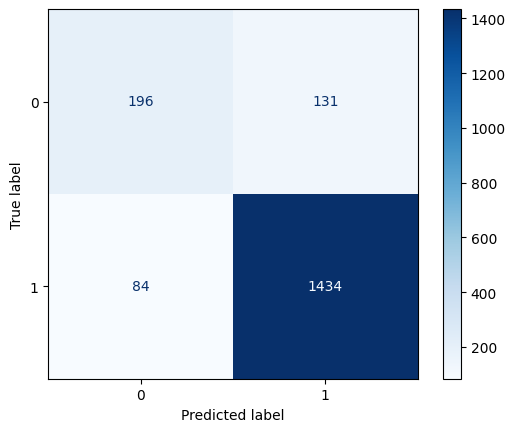

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')

### Matriz de Confusión

La matriz de confusión muestra el desempeño del modelo en cada clase:

- Verdaderos positivos (1 correctamente predicho): 1434
- Verdaderos negativos (0 correctamente predicho): 196
- Falsos positivos: 131
- Falsos negativos: 84

El modelo tiene un buen desempeño identificando correctamente a los clientes que recomiendan productos (clase 1).

Sin embargo, presenta mayor dificultad para identificar correctamente los casos en los que los clientes no recomiendan (clase 0), lo cual está relacionado con el desbalance en los datos.

En general, el modelo muestra un rendimiento sólido y es útil para identificar patrones en el comportamiento de los clientes.

## Conclusión

Se desarrolló un pipeline de aprendizaje automático capaz de predecir si un cliente recomendará un producto utilizando datos de texto, variables numéricas y categóricas.

El modelo de regresión logística, junto con técnicas de procesamiento de lenguaje natural (TF-IDF), logró un desempeño sólido.

El uso de GridSearchCV permitió optimizar el modelo, mejorando su capacidad de generalización.

Este enfoque demuestra la importancia de integrar correctamente el preprocesamiento y el modelado en un solo pipeline.